# Feature Selection and Model Creation

# 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import RFE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 2. Import Clean Dataset

In [2]:
dataset = pd.read_csv("Clean_Amazon_Dataset.csv")

print(dataset.shape)

dataset.head()

(1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,wayona nylon braided usb to lightning fast cha...,computers&accessories|accessories&peripherals|...,399.0,1099.0,64,4.2,24269.0,high compatibility compatible with iphone 12 ...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...",satisfiedcharging is really fastvalue for mone...,looks durable charging is fine toono complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,ambrane unbreakable 60w 3a fast charging 15m ...,computers&accessories|accessories&peripherals|...,199.0,349.0,43,4.0,43994.0,compatible with all type c enabled devices be ...,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...",a good braided cable for your type c devicegoo...,i ordered this cable to connect my phone to an...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,sounce fast phone charging cable data sync us...,computers&accessories|accessories&peripherals|...,199.0,1899.0,90,3.9,7928.0,fast charger data syncwith builtin safety pro...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...",good speed for earlier versionsgood productwor...,not quite durable and sturdyhttpsmmediaamazonc...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boat deuce usb 300 2 in 1 typec micro usb str...,computers&accessories|accessories&peripherals|...,329.0,699.0,53,4.2,94363.0,the boat deuce usb 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...",good productgood onenicereally nice productver...,good productlong wirecharges goodnicei bought ...,https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,portronics konnect l 12m fast charging 3a 8 pi...,computers&accessories|accessories&peripherals|...,154.0,399.0,61,4.2,16905.0,charge sync function this cable comes with ch...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...",as good as originaldecentgood one for secondar...,bought this instead of original apple does the...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


# 3. DATA ASSESSMENT

In [3]:
# Display the data types and non-null information for every column

dataset.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   int64  
 6   rating               1465 non-null   float64
 7   rating_count         1465 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [4]:
# Checks the number of missing values in each column.

dataset.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [5]:
# Checks whether duplicate records exist.

dataset.duplicated().sum()

np.int64(0)

# 4. Create Opportunity Score 

The Opportunity Score combines below features into one numerical score to provide single measure that represents the attractiveness of a product from Seller's perspective: 
1. Rating
2. Rating Count
3. Discount Percentage
4. Discount Price

In [6]:
# 1. Convert the customer rating from a 0–5 scale into a 0–100 score. 
# 2. Higher customer ratings produce higher rating scores, indicating better customer satisfaction.

dataset["rating_score"] = (dataset["rating"] / 5) * 100

In [7]:
dataset["rating_score"] 

0       84.0
1       80.0
2       78.0
3       84.0
4       84.0
        ... 
1460    80.0
1461    82.0
1462    72.0
1463    80.0
1464    86.0
Name: rating_score, Length: 1465, dtype: float64

In [8]:
# 1. Creates a normalized demand score using rating_count.
# 2. The product with the highest rating count receives a demand score of 100. Other products receive a proportional score.

dataset["demand_score"] = (dataset["rating_count"] / dataset["rating_count"].max()) * 100

In [9]:
dataset["demand_score"] 

0        5.683966
1       10.303696
2        1.856792
3       22.100461
4        3.959267
          ...    
1460     0.255285
1461     0.964464
1462     0.109609
1463     1.880915
1464     1.636403
Name: demand_score, Length: 1465, dtype: float64

In [10]:
# 1. Use the existing discount percentage directly as the discount score
# 2. Higher discount percentages contribute positively to the Opportunity Score

dataset["discount_score"] = (dataset["discount_percentage"])

In [11]:
dataset["discount_score"]

0       64
1       43
2       90
3       53
4       61
        ..
1460    59
1461    25
1462    28
1463    26
1464    22
Name: discount_score, Length: 1465, dtype: int64

In [12]:
# 1. Creates a price suitability score
# 2. Lower-priced products are considered more suitable for a new seller because the seller can potentially purchase more units while requiring
# less capital per product.

dataset["price_score"] = (1 - dataset["discounted_price"] / dataset["discounted_price"].max()) * 100

In [13]:
dataset["price_score"] 

0       99.488396
1       99.744839
2       99.744839
3       99.578151
4       99.802539
          ...    
1460    99.514040
1461    97.076548
1462    97.154763
1463    98.206180
1464    96.329017
Name: price_score, Length: 1465, dtype: float64

# 5. Calculate Opportunity Score

In [14]:
dataset["Opportunity_Score"] = (
    0.30 * dataset["rating_score"] +
    0.30 * dataset["demand_score"] +
    0.20 * dataset["discount_score"] +
    0.20 * dataset["price_score"]
)

In [15]:
dataset[[
    "discounted_price",
    "discount_percentage",
    "rating",
    "rating_count",
    "Opportunity_Score"
]].head()

,discounted_price,discount_percentage,rating,rating_count,Opportunity_Score
0,399.0,64,4.2,24269.0,59.602869
1,199.0,43,4.0,43994.0,55.640077
2,199.0,90,3.9,7928.0,61.906005
3,329.0,53,4.2,94363.0,62.345768
4,154.0,61,4.2,16905.0,58.548288


In [16]:
correlation = dataset[[
    "discounted_price",
    "discount_percentage",
    "rating",
    "rating_count",
    "Opportunity_Score"
]].corr()

correlation

,discounted_price,discount_percentage,rating,rating_count,Opportunity_Score
discounted_price,1.000000,-0.242412,0.120335,-0.027081,-0.448546
discount_percentage,-0.242412,1.000000,-0.155273,0.011097,0.750835
rating,0.120335,-0.155273,1.000000,0.101526,0.194006
rating_count,-0.027081,0.011097,0.101526,1.000000,0.544119
Opportunity_Score,-0.448546,0.750835,0.194006,0.544119,1.000000


# 6. Select Clustering Features

In [17]:
clustering_features = [
    "discounted_price",
    "discount_percentage",
    "rating",
    "rating_count",
    "Opportunity_Score"
]

X = dataset[clustering_features]

X.head()

,discounted_price,discount_percentage,rating,rating_count,Opportunity_Score
0,399.0,64,4.2,24269.0,59.602869
1,199.0,43,4.0,43994.0,55.640077
2,199.0,90,3.9,7928.0,61.906005
3,329.0,53,4.2,94363.0,62.345768
4,154.0,61,4.2,16905.0,58.548288


# 7. Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[-0.39273074,  0.75402906,  0.35479199,  0.14027091,  0.83113416],
       [-0.42154116, -0.21691117, -0.33137337,  0.60207613,  0.17271378],
       [-0.42154116,  1.95614555, -0.67445605, -0.2423075 ,  1.21380169],
       ...,
       [-0.13055596, -0.91043991, -1.70370409, -0.41696235, -1.31869423],
       [-0.24867867, -1.00291041, -0.33137337, -0.23989604, -0.8631632 ],
       [-0.03778643, -1.18785141,  0.69787467, -0.26433836, -0.77157871]],
      shape=(1465, 5))

# 8. K-Means Clustering - Elbow Method

In [19]:
from sklearn.cluster import KMeans

In [20]:
wcss = []

for i in range(2, 8):
    
    kmeans = KMeans(
        n_clusters=i,
        random_state=0,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

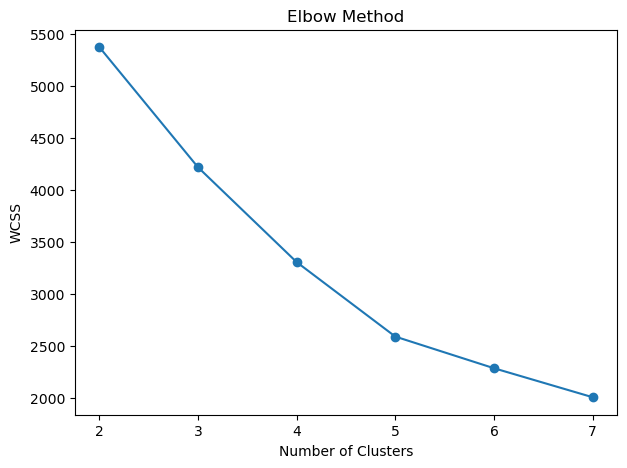

In [21]:
# Elbow Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    range(2,8),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

# 9. Silhouette Score

In [22]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

for i in range(2, 8):
    
    kmeans = KMeans(
        n_clusters=i,
        random_state=0,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        cluster_labels
    )
    
    silhouette_scores.append(score)

C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

In [23]:
for i, score in zip(range(2,8), silhouette_scores):
    
    print(
        "Number of Clusters:",
        i,
        "Silhouette Score:",
        score
    )

Number of Clusters: 2 Silhouette Score: 0.3056277546108305
Number of Clusters: 3 Silhouette Score: 0.3386790349506631
Number of Clusters: 4 Silhouette Score: 0.3277782835335672
Number of Clusters: 5 Silhouette Score: 0.32898006551746345
Number of Clusters: 6 Silhouette Score: 0.27466676172552085
Number of Clusters: 7 Silhouette Score: 0.28316991543102615


# 10. Silhouette Plot

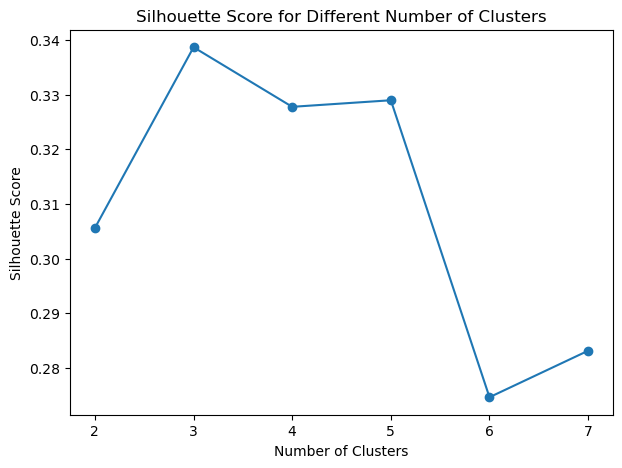

In [24]:
plt.figure(figsize=(7,5))

plt.plot(
    range(2,8),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Number of Clusters")

plt.show()

# 11. Final K-Means Model

In [25]:
kmeans = KMeans(
    n_clusters=3,
    random_state=0,
    n_init=10
)

dataset["Cluster"] = kmeans.fit_predict(X_scaled)

C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [26]:
dataset["Cluster"].value_counts()

Cluster
2    892
1    538
0     35
Name: count, dtype: int64

# 12. Average Opportunity Score by Cluster

In [27]:
cluster_summary = dataset.groupby("Cluster").agg(
    
    Average_Opportunity_Score=(
        "Opportunity_Score",
        "mean"
    ),
    
    Average_Discounted_Price=(
        "discounted_price",
        "mean"
    ),
    
    Average_Discount_Percentage=(
        "discount_percentage",
        "mean"
    ),
    
    Average_Rating=(
        "rating",
        "mean"
    ),
    
    Average_Rating_Count=(
        "rating_count",
        "mean"
    ),
    
    Product_Count=(
        "Cluster",
        "count"
    )
)

cluster_summary = cluster_summary.sort_values(
    "Average_Opportunity_Score",
    ascending=False
)

cluster_summary

,Average_Opportunity_Score,Average_Discounted_Price,Average_Discount_Percentage,Average_Rating,Average_Rating_Count,Product_Count
Cluster,,,,,,
0,71.990857,1489.342857,51.514286,4.188571,241076.114286,35
2,57.368721,1012.489529,61.062780,4.077130,13563.941704,892
1,48.879673,6734.782100,25.273234,4.122862,11598.578067,538


# 13. Assign BUY / CONSIDER / DON'T BUY

In [28]:
buy_cluster = cluster_summary.index[0]

consider_cluster = cluster_summary.index[1]

dont_buy_cluster = cluster_summary.index[2]


cluster_mapping = {
    
    buy_cluster: "BUY",
    
    consider_cluster: "CONSIDER",
    
    dont_buy_cluster: "DON'T BUY"
}


dataset["Recommendation"] = dataset["Cluster"].map(
    cluster_mapping
)

In [29]:
dataset[
    [
        "discounted_price",
        "discount_percentage",
        "rating",
        "rating_count",
        "Opportunity_Score",
        "Cluster",
        "Recommendation"
    ]
].head(20)

,discounted_price,discount_percentage,rating,rating_count,Opportunity_Score,Cluster,Recommendation
0,399.00,64,4.2,24269.0,59.602869,2,CONSIDER
1,199.00,43,4.0,43994.0,55.640077,2,CONSIDER
2,199.00,90,3.9,7928.0,61.906005,2,CONSIDER
3,329.00,53,4.2,94363.0,62.345768,2,CONSIDER
4,154.00,61,4.2,16905.0,58.548288,2,CONSIDER
5,149.00,85,3.9,24871.0,62.109278,2,CONSIDER
6,176.63,65,4.1,15188.0,58.621845,2,CONSIDER
7,229.00,23,4.3,30411.0,52.478014,1,DON'T BUY
8,499.00,50,4.2,179691.0,67.697494,0,BUY
9,199.00,33,4.0,43994.0,53.640077,1,DON'T BUY


# 14. Check the Final Silhuoette Score

In [30]:
silhouette_final = silhouette_score(
    X_scaled,
    dataset["Cluster"]
)

print(
    "Final Silhouette Score:",
    silhouette_final
)

Final Silhouette Score: 0.3386790349506631


# 15. MODEL SELECTION

In [31]:
import pickle

final_model = {
    "kmeans": kmeans,
    "scaler": scaler,
    "cluster_mapping": cluster_mapping,
    "rating_count_max": dataset["rating_count"].max(),
    "discounted_price_max": dataset["discounted_price"].max()
}

pickle.dump(
    final_model,
    open("finalized_model_KMeans.sav", "wb")
)

# Overall Inference:

1. K-Means Clustering is an unsupervised machine learning technique used to group similar products together based on their characteristics.

2. In this project, there are no predefined labels such as BUY, CONSIDER, or DON'T BUY in the original data. Therefore, instead of manually assigning 
these labels, K-Means is used to discover natural groups within the products.

3. Since this is an unsupervised model, there is no actual BUY/CONSIDER/DON'T BUY target against which we can calculate accuracy.

4. Therefore, the Silhouette Score is used to measures how well the products fit within their assigned cluster and how clearly separated that cluster is from the other clusters. A higher score indicates better-defined clusters.